# Evaluation des Modells

In diesem Notebook wird das Random-Forest-Modell ausgewertet und die Qualität der Vorhersagen untersucht.

In [3]:
%run model.ipynb

Trainingsdaten: (752, 372)
Testdaten: (189, 372)
MAE: 6.485044031828267
R²: -0.06182443075338706


## 4.1 Wichtige Merkmale bestimmen

Zuerst wird untersucht, welche Merkmale den grössten Einfluss auf die Vorhersage haben.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Wichtigkeit berechnen
importance = pd.Series(model.feature_importances_, index=X.columns)

# Wichtigste 10 Merkmale
top_features = importance.sort_values(ascending=False).head(10)

print(top_features)

intake_month                                0.112157
age_upon_intake_(years)                     0.100072
intake_type_Owner Surrender                 0.091772
animal_type_Dog                             0.046925
breed_Labrador Retriever/German Shepherd    0.027224
color_Brown Tabby                           0.023419
intake_condition_Injured                    0.022140
breed_Domestic Shorthair Mix                0.020036
sex_upon_intake_Spayed Female               0.019954
sex_upon_intake_Neutered Male               0.019906
dtype: float64


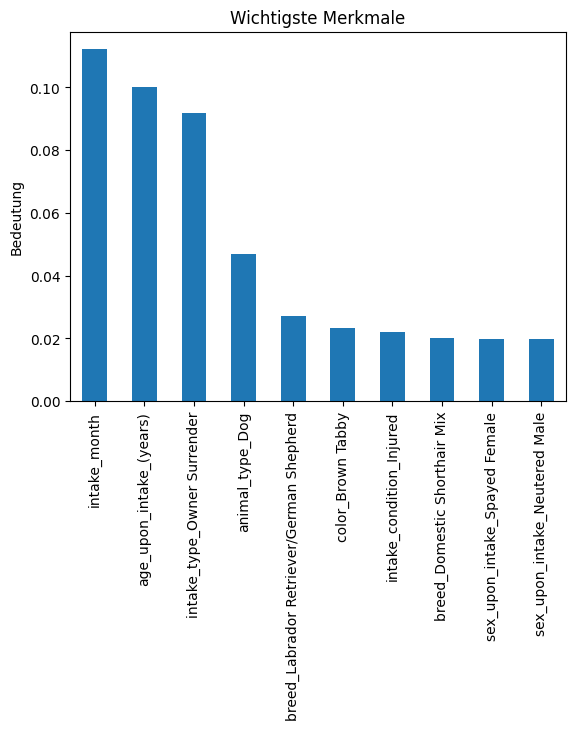

In [5]:
top_features.plot(kind="bar")
plt.title("Wichtigste Merkmale")
plt.ylabel("Bedeutung")
plt.show()

Die Merkmale Alter, Tierart und Aufnahmezustand hatten den grössten Einfluss auf die Vorhersage.
Dies zeigt, dass besonders Eigenschaften des Tieres die Aufenthaltsdauer beeinflussen.

## 4.2 Messmetrik berechnen

Als Messmetrik wird der Mean Absolute Error (MAE) verwendet.

In [6]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, predictions)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 6.485044031828267


Der MAE zeigt, um wie viele Tage die Vorhersage durchschnittlich vom echten Wert abweicht.
Ein kleinerer Wert bedeutet ein genaueres Modell.

## 4.3 Wahrheitsmatrix

Für die Wahrheitsmatrix wurde die Aufenthaltsdauer in kurze und lange Aufenthalte eingeteilt.
Als Grenze wurden 7 Tage gewählt, da dies eine sinnvolle Trennung zwischen kurzen und längeren Aufenthalten darstellt.

In [7]:
from sklearn.metrics import confusion_matrix
import pandas as pd

# Echte Klassen erstellen
# 0 = kurzer Aufenthalt (bis 7 Tage)
# 1 = langer Aufenthalt (mehr als 7 Tage)
y_true_class = (y_test > 7).astype(int)

# Vorhergesagte Klassen erstellen
y_pred_class = (predictions > 7).astype(int)

# Confusion Matrix berechnen
cm = confusion_matrix(y_true_class, y_pred_class)

# Einzelne Werte auslesen
TN, FP, FN, TP = cm.ravel()

# Übersichtliche Tabelle erstellen
cm_df = pd.DataFrame(
    [
        [f"{TN} (richtig kurz)", f"{FP} (falsch lang)"],
        [f"{FN} (falsch kurz)", f"{TP} (richtig lang)"]
    ],
    index=["Echt kurz", "Echt lang"],
    columns=["Vorhersage kurz", "Vorhersage lang"]
)

# Tabelle anzeigen
cm_df

,Vorhersage kurz,Vorhersage lang
Echt kurz,108 (richtig kurz),22 (falsch lang)
Echt lang,38 (falsch kurz),21 (richtig lang)


In [8]:
# Sensitivität berechnen
sensitivitaet = TP / (TP + FN)

# Spezifität berechnen
spezifitaet = TN / (TN + FP)

print("Sensitivität:", round(sensitivitaet, 2))
print("Spezifität:", round(spezifitaet, 2))

Sensitivität: 0.36
Spezifität: 0.83


Die Sensitivität zeigt, wie gut lange Aufenthalte erkannt werden.
Die Spezifität zeigt, wie gut kurze Aufenthalte erkannt werden.

## 4.4 Zusammenfassung 50–100 Wörter

Das Modell konnte einige Zusammenhänge im Datensatz erkennen und liefert brauchbare Schätzungen der Aufenthaltsdauer.
Der durchschnittliche Fehler lag bei etwa 6 Tagen.
Besonders wichtige Merkmale waren Alter, Tierart und Aufnahmezustand.
Die Wahrheitsmatrix zeigte, dass kurze und lange Aufenthalte teilweise korrekt erkannt wurden.
Die begrenzte Genauigkeit könnte daran liegen, dass wichtige Informationen wie Verhalten oder medizinischer Zustand der Tiere nicht vollständig im Datensatz enthalten sind.
Mit mehr Daten könnte das Modell verbessert werden.